# **Project Title:** Diabetes Prediction Analysis

# **Course:** CSC 405-Data Science Spring 2026

# **Team Members:** Adrian Aldridge, Eman Dweik, Sarah Robinson

# **Dataset Source:**
## https://www.kaggle.com/datasets/miadul/synthetic-diabetes-prediction-dataset




In [18]:
# set up

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


df = pd.read_csv('diabetes_clean.csv')
X = df.drop('diabetes', axis=1)
y = df['diabetes']

categorical_cols = ['gender', 'physical_activity']
numerical_cols = [col for col in X.columns if col not in categorical_cols]


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}


lin_reg = LinearRegression()

for name, model in models.items():
    model.fit(X_train_processed, y_train)
lin_reg.fit(X_train_processed, y_train)


probas = {}
for name, model in models.items():
    probas[name] = model.predict_proba(X_test_processed)[:, 1]
probas['Linear Regression'] = lin_reg.predict(X_test_processed)  



### **Figure 1:** Data Exploration

The figure below showcases the distribution of diabetes. Based on the distribution shown below, we can infer that the distribution is mostly balanced. 

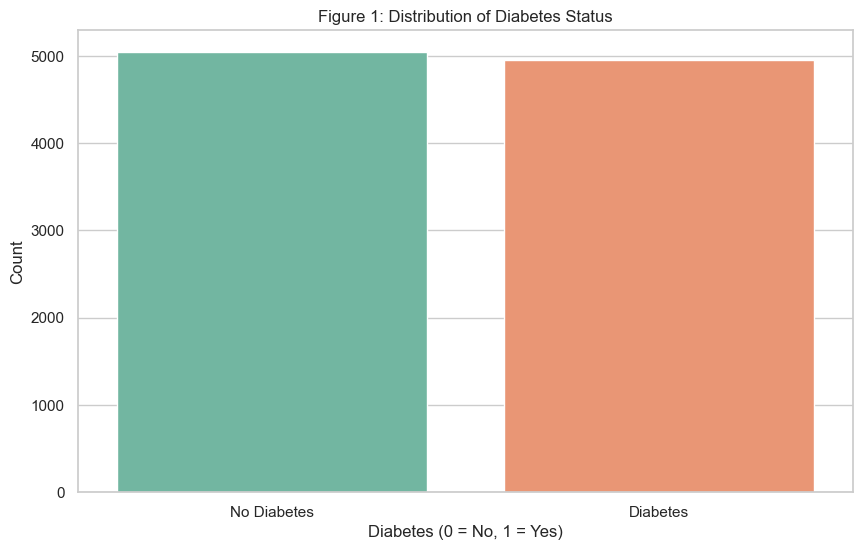

In [20]:
plt.figure()
sns.countplot(x='diabetes', data=df, hue='diabetes', palette='Set2', legend=False)
plt.title('Figure 1: Distribution of Diabetes Status')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

## **Figure 2:** Data Exploration

The figure below is a correlation heat map of the numerical features of the data set. All numerical features have very low correlation with each other and with the target, which indicates weak linear relationships.

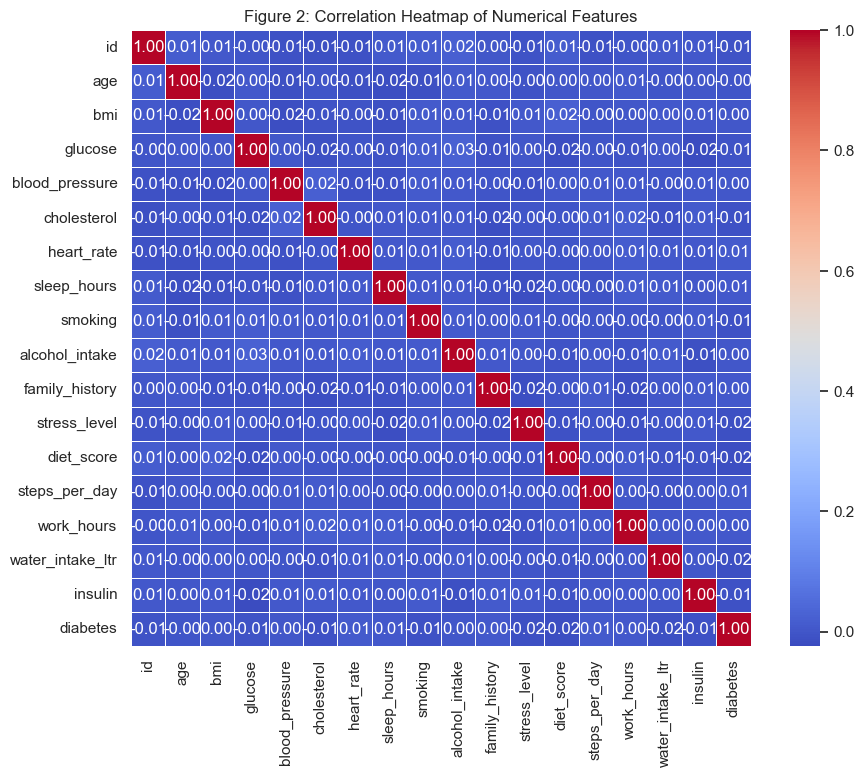

In [25]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Figure 2: Correlation Heatmap of Numerical Features')
plt.show()

### **Figure 3:** Statistical Analysis

The figure shown below is a box plot of Glucose Levels by diabetic status. Glucose levels show substantial overlap between the two groups; the t-test previously done confirmed no significant difference (p > 0.05)

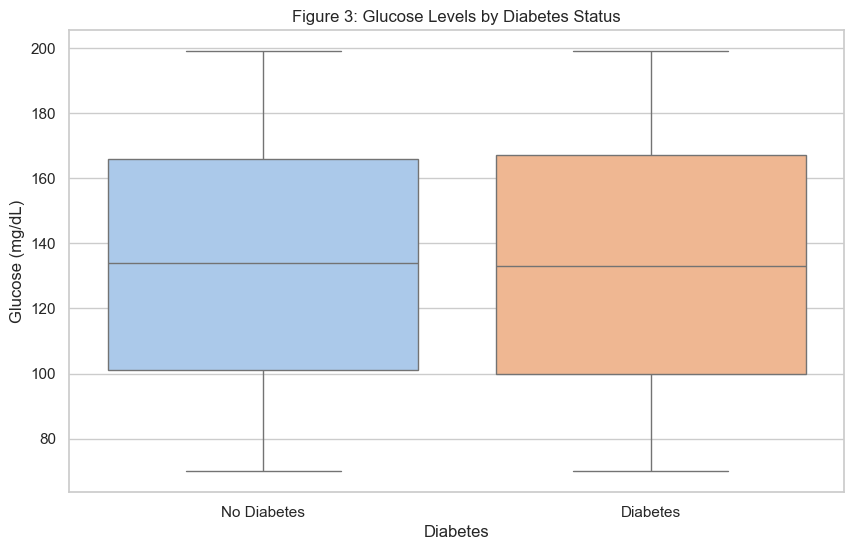

In [24]:
plt.figure()
sns.boxplot(x='diabetes', y='glucose', data=df, hue='diabetes', palette='pastel', legend=False)
plt.title('Figure 3: Glucose Levels by Diabetes Status')
plt.xlabel('Diabetes')
plt.ylabel('Glucose (mg/dL)')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()

### **Figure 4:** Model Results

The figure below shows a bar chart meant to visualize the comparison of model performance. All models perform slightly better than random guessing (ROC-AUC ~0.5). Random Forest is only marginally better than the rest.

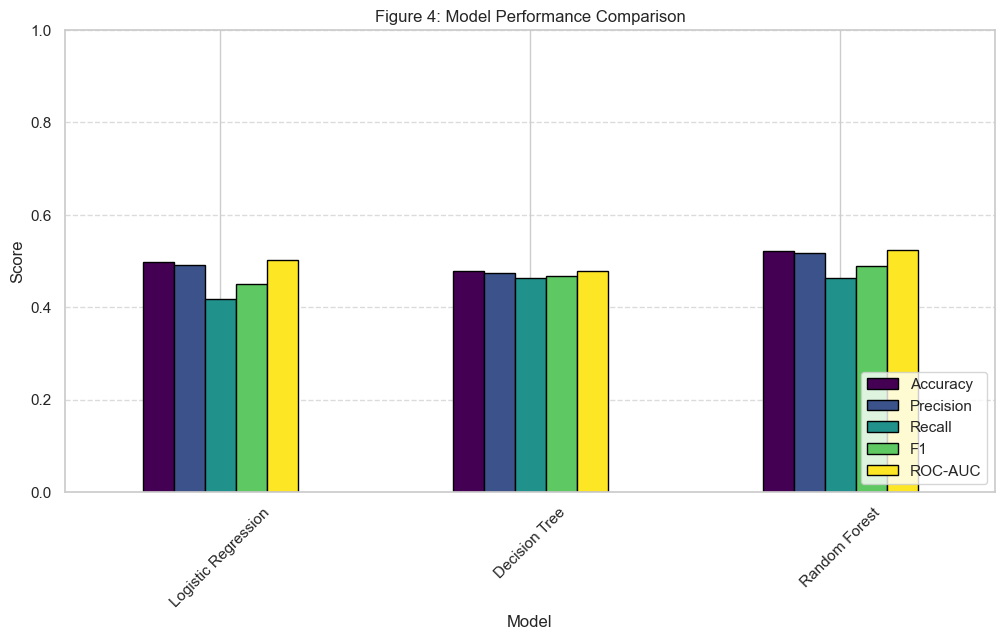

In [23]:
metrics = {}
for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    metrics_df = pd.DataFrame(metrics).T
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']]

ax = metrics_df.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title('Figure 4: Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Figure 5:** Multi-panel Figure

The figure below is a Multi-panel ROC curve graph. ROC curves lie close to the diagonal; this can imply poor discriminative power of the features in this synthetic dataset.

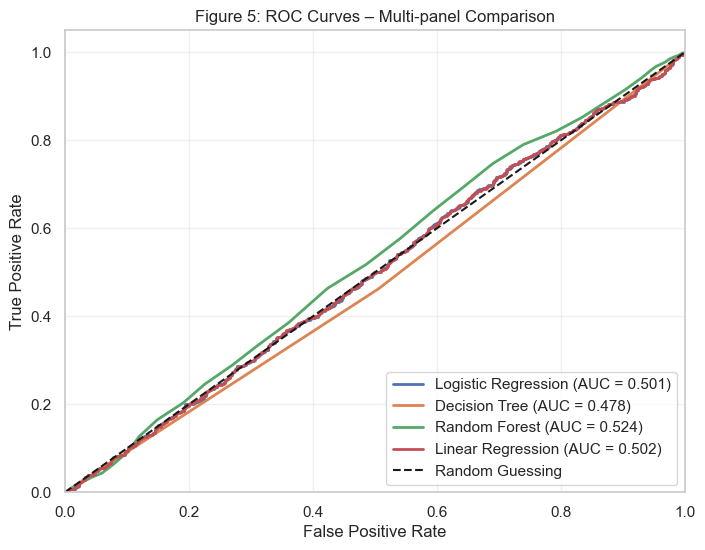

In [14]:
plt.figure(figsize=(8, 6))
for name, y_proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 5: ROC Curves – Multi-panel Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### **Figure 6:** Final Insights

The figure below is a bar plot showing the important features of Random Forest. Based on the figure, we can infer that no single feature dominates; the most important features have low importance scores, which can imply a multifactorial nature.

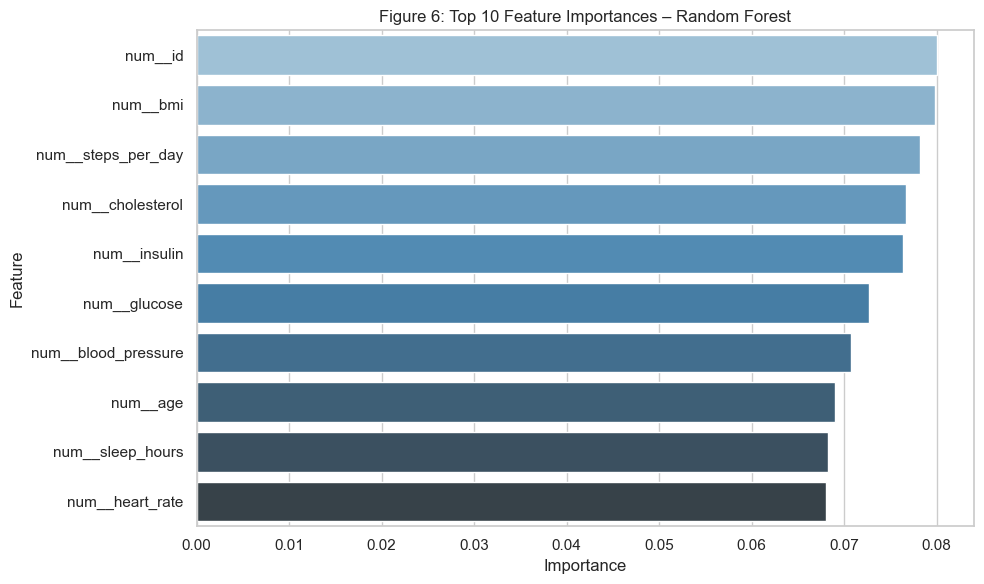

In [17]:
try:
    feature_names = preprocessor.get_feature_names_out()
    importances = models['Random Forest'].feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
except:
    dummy_cols = []
    for cat in categorical_cols:
        unique = df[cat].unique()
        for val in unique[1:]:
            dummy_cols.append(f"{cat}_{val}")
    all_features = numerical_cols + dummy_cols
    importances = models['Random Forest'].feature_importances_
    imp_df = pd.DataFrame({'feature': all_features, 'importance': importances})

imp_df = imp_df.sort_values('importance', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='importance', y='feature', hue='feature', palette='Blues_d', legend=False)
plt.title('Figure 6: Top 10 Feature Importances – Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
